# Electricity NPV summary

Run the electricity Monte Carlo mean NPV, deterministic NPV, and Monte Carlo ranking summaries. This notebook displays figures inline only; it does not save figures or CSV files.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_deterministic import calculate_deterministic_electricity_results
from electricity.electricity_npv_monte_carlo import DEFAULT_RANDOM_SEED, DEFAULT_SAMPLE_SIZE, simulate_electricity_results
from electricity.electricity_npv_summary_figures import (
    ELECTRICITY_TECHNOLOGY_LABELS,
    calculate_electricity_npv_rankings_from_results,
)


## Settings

In [2]:
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
TECHNOLOGIES = tuple(ELECTRICITY_TECHNOLOGY_LABELS)

BAR_COLOR = "#4472C4"
POSITIVE_COLOR = "#4EA72E"
NEGATIVE_COLOR = "#FF0F0F"

pd.options.display.float_format = "{:,.3f}".format


## Plot helpers

In [3]:
def display_label(technology: str) -> str:
    return ELECTRICITY_TECHNOLOGY_LABELS.get(technology, technology)


def monte_carlo_npv_summary(results_by_technology):
    rows = []
    for technology, results in results_by_technology.items():
        values = np.asarray(results["npv_eur"], dtype=float) / 1_000_000
        rows.append(
            {
                "technology": technology,
                "label": display_label(technology),
                "mean_m_eur": values.mean(),
                "median_m_eur": np.median(values),
                "p05_m_eur": np.percentile(values, 5),
                "p95_m_eur": np.percentile(values, 95),
            }
        )
    return pd.DataFrame(rows).sort_values("mean_m_eur", ascending=False).reset_index(drop=True)


def deterministic_npv_summary(results_by_technology):
    rows = []
    for technology, results in results_by_technology.items():
        rows.append(
            {
                "technology": technology,
                "label": display_label(technology),
                "npv_m_eur": float(np.asarray(results["npv_eur"]).item()) / 1_000_000,
            }
        )
    return pd.DataFrame(rows).sort_values("npv_m_eur", ascending=False).reset_index(drop=True)


def plot_monte_carlo_mean_npv(summary: pd.DataFrame):
    labels = summary["label"].tolist()
    means = summary["mean_m_eur"].to_numpy()
    medians = summary["median_m_eur"].to_numpy()
    p05 = summary["p05_m_eur"].to_numpy()
    p95 = summary["p95_m_eur"].to_numpy()
    colors = [POSITIVE_COLOR if value >= 0 else NEGATIVE_COLOR for value in means]

    fig, ax = plt.subplots(figsize=(9.5, max(5.0, 0.52 * len(labels) + 1.7)), dpi=150)
    y_positions = np.arange(len(labels))
    ax.barh(y_positions, means, color=colors, height=0.42, label="Mean")
    ax.errorbar(
        means,
        y_positions,
        xerr=[means - p05, p95 - means],
        fmt="none",
        ecolor="#4d4d4d",
        elinewidth=1.1,
        capsize=3,
        label="5th-95th percentile",
    )
    ax.scatter(medians, y_positions, color="white", edgecolor="#333333", s=26, zorder=3, label="Median")

    margin = max(60.0, 0.12 * max(abs(p05).max(), abs(p95).max()))
    ax.set_xlim(p05.min() - margin, p95.max() + margin)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontsize=9, color="#5a5a5a")
    ax.invert_yaxis()
    ax.axvline(0, color="#bbbbbb", linewidth=1.1)
    ax.set_title("Monte Carlo mean NPV by electricity technology", fontsize=14, color="#444444", pad=12)
    ax.set_xlabel("NPV (million EUR)", fontsize=9, color="#5a5a5a")
    ax.grid(axis="x", color="#e6e6e6", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(loc="lower right", fontsize=8, frameon=False)
    ax.text(
        0,
        -0.12,
        f"Sample size: {SAMPLE_SIZE:,}; random seed: {RANDOM_SEED}. Bars show mean NPV; whiskers show simulated 5th-95th percentiles.",
        transform=ax.transAxes,
        fontsize=8.5,
        color="#5a5a5a",
    )
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.show()


def plot_deterministic_npv(summary: pd.DataFrame):
    labels = summary["label"].tolist()
    values = summary["npv_m_eur"].to_numpy()
    colors = [POSITIVE_COLOR if value >= 0 else NEGATIVE_COLOR for value in values]

    fig, ax = plt.subplots(figsize=(8.5, max(4.8, 0.48 * len(labels) + 1.5)), dpi=150)
    y_positions = np.arange(len(labels))
    ax.barh(y_positions, values, color=colors, height=0.42)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontsize=9, color="#5a5a5a")
    ax.invert_yaxis()
    ax.axvline(0, color="#bbbbbb", linewidth=1.1)
    ax.set_title("Deterministic NPV by electricity technology", fontsize=14, color="#444444", pad=12)
    ax.set_xlabel("NPV (million EUR)", fontsize=9, color="#5a5a5a")
    ax.grid(axis="x", color="#e6e6e6", linewidth=0.8)
    ax.set_axisbelow(True)
    for y_position, value in zip(y_positions, values):
        offset = 35 if value >= 0 else -35
        ax.text(value + offset, y_position, f"{value:,.0f}", va="center", ha="left" if value >= 0 else "right", fontsize=8.5, color="#333333")
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.show()


def plot_ranking_summary(ranking_summary: pd.DataFrame):
    sorted_summary = ranking_summary.sort_values(["average_rank", "technology"]).reset_index(drop=True)
    labels = sorted_summary["technology"].map(ELECTRICITY_TECHNOLOGY_LABELS).fillna(sorted_summary["technology"]).tolist()
    rank_count_columns = sorted(
        [column for column in sorted_summary.columns if column.startswith("rank_") and column.endswith("_count")],
        key=lambda column: int(column.removeprefix("rank_").removesuffix("_count")),
    )
    average_ranks = sorted_summary["average_rank"].astype(float).to_numpy()
    rank_counts = sorted_summary[rank_count_columns].astype(int)
    rank_numbers = [int(column.removeprefix("rank_").removesuffix("_count")) for column in rank_count_columns]

    fig, (ax, count_ax) = plt.subplots(
        1,
        2,
        figsize=(14.0, max(5.6, 0.58 * len(labels) + 2.2)),
        dpi=150,
        gridspec_kw={"width_ratios": [1.55, 1.45], "wspace": 0.13},
    )
    y_positions = np.arange(len(labels))
    ax.barh(y_positions, average_ranks, color=BAR_COLOR, height=0.42)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontsize=9, color="#5a5a5a")
    ax.invert_yaxis()
    ax.set_title("Average rank", fontsize=12, color="#4d4d4d", pad=10)
    ax.set_xlabel("Mean rank across simulations (1 = highest NPV)", fontsize=9, color="#5a5a5a")
    ax.set_xlim(0, max(9, average_ranks.max()) + 3.6)
    ax.set_xticks(range(1, 10))
    ax.grid(axis="x", color="#e6e6e6", linewidth=0.8)
    ax.set_axisbelow(True)

    for y_position, row in sorted_summary.iterrows():
        ax.text(
            row["average_rank"] + 0.22,
            y_position,
            f"avg {row['average_rank']:.2f} | rank 1 {row['probability_rank_1']:.1%} | top 3 {row['probability_top_3']:.1%}",
            va="center",
            ha="left",
            fontsize=8.5,
            color="#333333",
        )

    count_cmap = LinearSegmentedColormap.from_list("rank_counts_blue", ["#f7f9fc", "#d9e5f6", BAR_COLOR])
    count_ax.imshow(rank_counts, aspect="auto", cmap=count_cmap)
    count_ax.set_title("Number of simulations by rank", fontsize=12, color="#4d4d4d", pad=10)
    count_ax.set_xticks(range(len(rank_numbers)))
    count_ax.set_xticklabels([f"{rank}\n(best)" if rank == 1 else f"{rank}\n(worst)" if rank == max(rank_numbers) else str(rank) for rank in rank_numbers], fontsize=8, color="#5a5a5a")
    count_ax.set_yticks(y_positions)
    count_ax.set_yticklabels([])
    count_ax.tick_params(axis="both", length=0)
    count_ax.set_xlabel("Rank reached in a simulation", fontsize=9, color="#5a5a5a")

    max_count = int(rank_counts.to_numpy().max())
    for y_position, row in enumerate(rank_counts.to_numpy()):
        for x_position, count in enumerate(row):
            text_color = "white" if max_count and count > max_count * 0.55 else "#333333"
            count_ax.text(x_position, y_position, f"{count:,}", ha="center", va="center", fontsize=7.2, color=text_color)

    fig.suptitle("Monte Carlo NPV ranking", fontsize=15, color="#444444", y=0.98)
    fig.text(0.01, 0.025, f"Ranks are calculated within each Monte Carlo simulation by NPV. Sample size: {SAMPLE_SIZE:,}; random seed: {RANDOM_SEED}.", fontsize=8.5, color="#5a5a5a")
    for axis in (ax, count_ax):
        for spine in axis.spines.values():
            spine.set_visible(False)
    fig.subplots_adjust(left=0.12, right=0.985, top=0.86, bottom=0.14, wspace=0.13)
    plt.show()


## Monte Carlo mean NPV

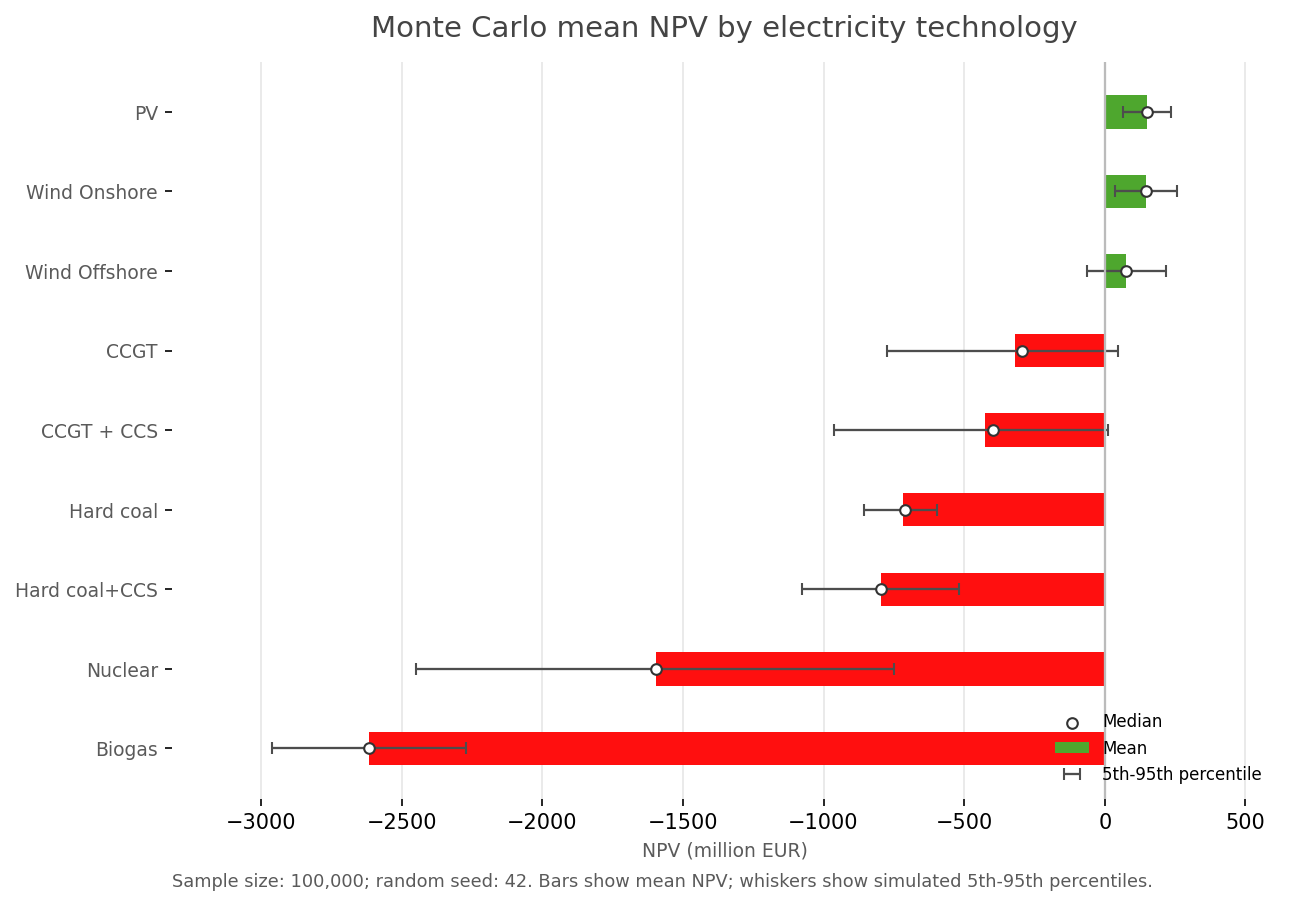

In [4]:
monte_carlo_results = simulate_electricity_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=TECHNOLOGIES,
)
mc_summary = monte_carlo_npv_summary(monte_carlo_results)
plot_monte_carlo_mean_npv(mc_summary)


## Deterministic NPV

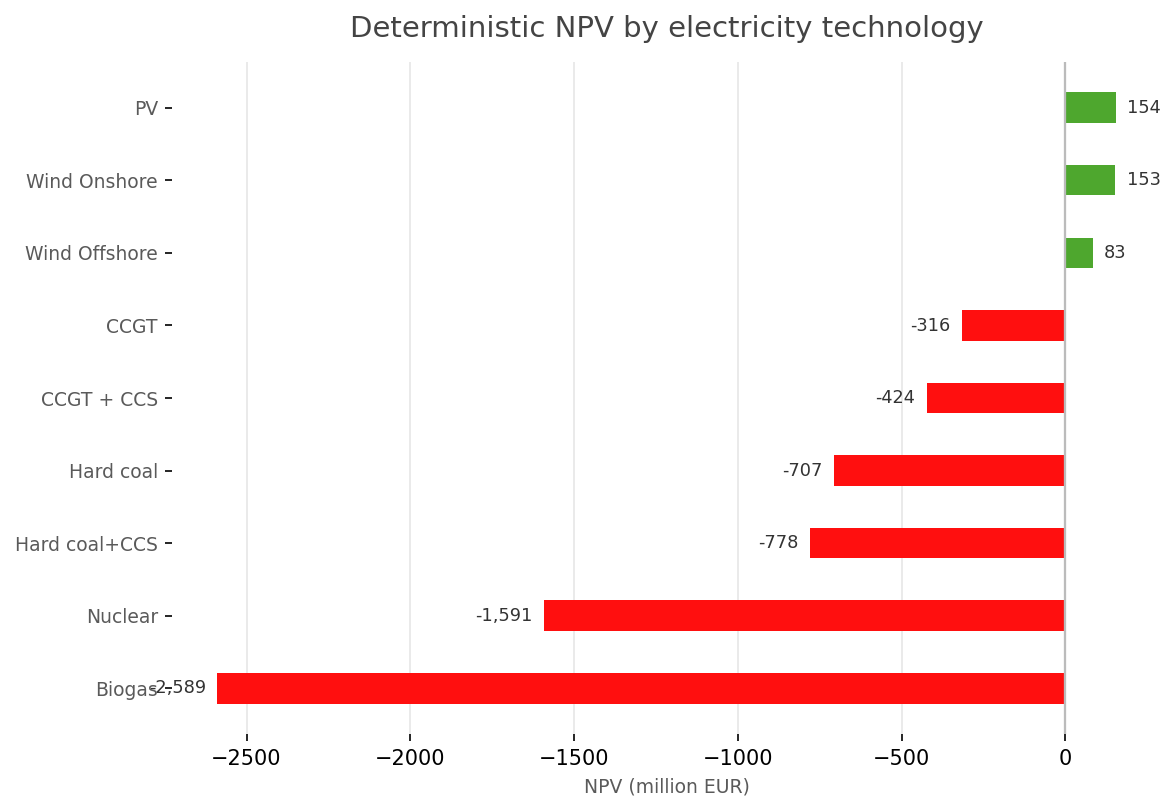

In [5]:
deterministic_results = calculate_deterministic_electricity_results(technologies=TECHNOLOGIES)
det_summary = deterministic_npv_summary(deterministic_results)
plot_deterministic_npv(det_summary)


## Monte Carlo NPV ranking

,Technology,Average rank,Probability rank 1,Probability top 3,Simulations
0,PV,1.772,0.411,0.994,100000
1,Wind Onshore,1.829,0.415,0.988,100000
2,Wind Offshore,2.528,0.169,0.920,100000
3,CCGT,4.487,0.002,0.060,100000
4,CCGT + CCS,4.905,0.002,0.038,100000
5,Hard coal,6.122,0.000,0.000,100000
6,Hard coal+CCS,6.509,0.000,0.000,100000
7,Nuclear,7.875,0.000,0.000,100000
8,Biogas,8.972,0.000,0.000,100000


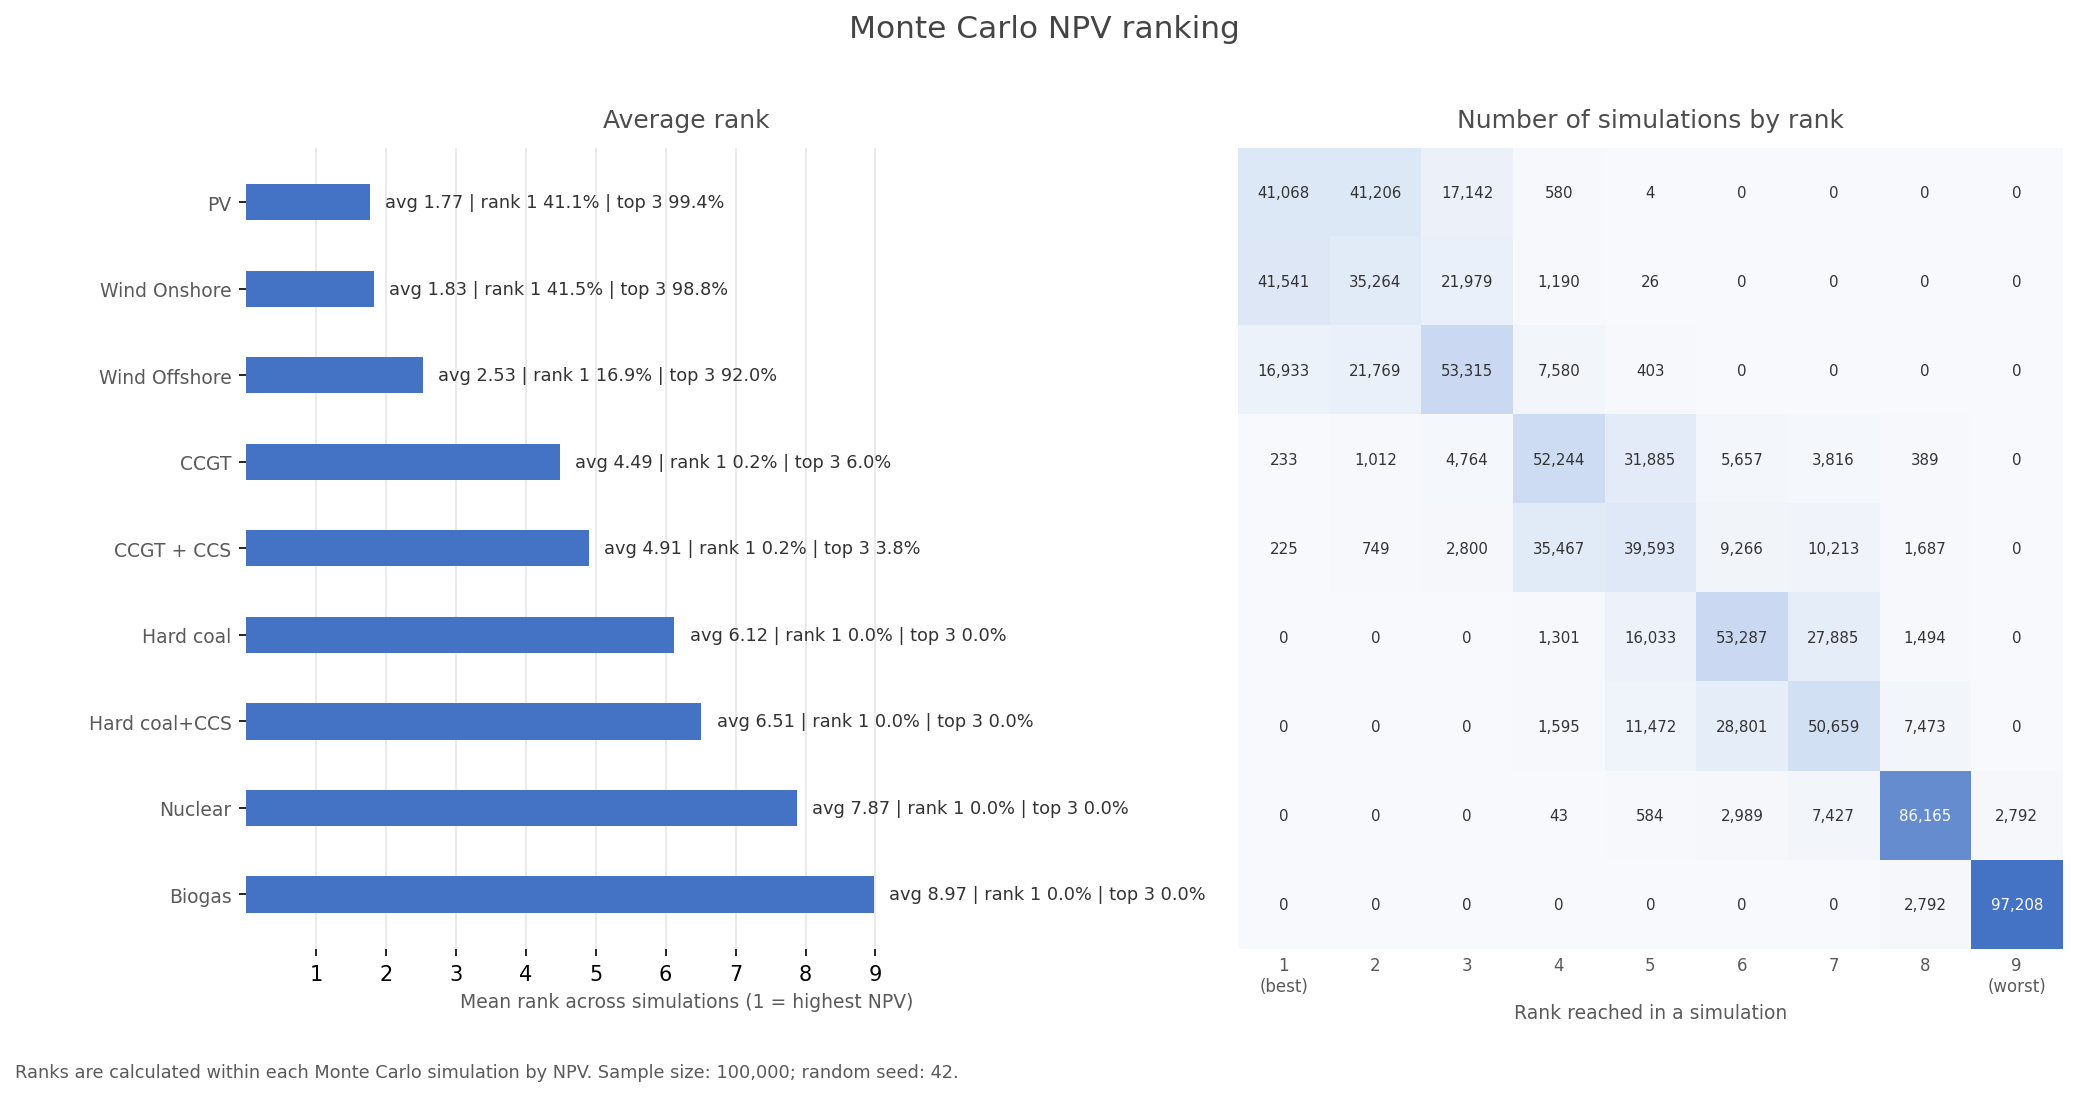

In [6]:
ranking_raw, ranking_summary = calculate_electricity_npv_rankings_from_results(
    results=monte_carlo_results,
    sector_name="Electricity",
)

rank_table = (
    ranking_summary.assign(technology=ranking_summary["technology"].map(ELECTRICITY_TECHNOLOGY_LABELS).fillna(ranking_summary["technology"]))
    .loc[:, ["technology", "average_rank", "probability_rank_1", "probability_top_3", "n_simulations"]]
    .rename(
        columns={
            "technology": "Technology",
            "average_rank": "Average rank",
            "probability_rank_1": "Probability rank 1",
            "probability_top_3": "Probability top 3",
            "n_simulations": "Simulations",
        }
    )
)
display(rank_table)
plot_ranking_summary(ranking_summary)
